# El extraño caso del Titanic Espacial

## Introducción

Seleccionamos el problema hipotetico de predecir el resultado de una colisión espacial en la cual los pasajeros de una nave pudieron (o no) ser transportados a otra dimesión. Para solucionar este problema buscamos un modelo que según ciertas entradas pueda predecir si un pasajero fue transportado o no, por esto buscamos el desarrollo de un modelo de clasificación para nuestra variable "Transported" de tipo booleana.

Nuestros datos provienen de una competencia en kaggle llamada Spacship Titanic a la cual se puede acceder desde el siguiente link:

https://www.kaggle.com/competitions/spaceship-titanic


## Conjunto de datos

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
%matplotlib inline

In [ ]:
data_set = pd.read_csv("/content/train.csv")


data_set.head(5)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


## Exploración de los datos

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.dummy import DummyClassifier
%matplotlib inline

En esta primera celda de código podemos ver que extraemos los datos en un csv y lo almacenamos en la variable:
```
data_set
```
adicional podemos ver las primeras 5 entradas de nuestros datos.

In [ ]:
data_set = pd.read_csv("/content/train.csv")
data_set.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [ ]:
print (data_set.shape)


(8693, 14)


In [ ]:
for c in data_set.columns:
    print ("%20s"%c, data_set[c].dtype)

         PassengerId object
          HomePlanet object
           CryoSleep object
               Cabin object
         Destination object
                 Age float64
                 VIP object
         RoomService float64
           FoodCourt float64
        ShoppingMall float64
                 Spa float64
              VRDeck float64
                Name object
         Transported bool


Podemos ver que nuestro conjunto de datos tiene un total de 8693 datos con 14 variables medidas, dichas variables son de diversos tipos; numericos como spa, VRDeck o Age, asi como categoricas tomando de ejemplo a HomePlanet y hasta booleanas con CryoSleep.

En las siguientes celdaa podemos ver la cantidad y porcentajes de valores perdidos durante la recuperación de los datos.

In [ ]:
num_Na = data_set.isna().sum()
percentage_Na = num_Na
print("Número de valores perdidos por variable: \n")
k = data_set.isna().sum()
k


Número de valores perdidos por variable: 



,0
PassengerId,0
HomePlanet,201
CryoSleep,217
Cabin,199
Destination,182
Age,179
VIP,203
RoomService,181
FoodCourt,183
ShoppingMall,208


In [ ]:
print("\nPorcentaje de valores perdidos por variable: \n")
k*100/data_set.shape[0]


Porcentaje de valores perdidos por variable: 



,0
PassengerId,0.000000
HomePlanet,2.312205
CryoSleep,2.496261
Cabin,2.289198
Destination,2.093639
Age,2.059128
VIP,2.335212
RoomService,2.082135
FoodCourt,2.105142
ShoppingMall,2.392730


En nuestros registros vemos que hay valores perdidos o anotados como NaN. Estos no representan un problema debido a su cantidad (~2%), gracias a esto podemos, hasta ahora, podemos tener a todas las variables en consideración para ajustar el modelo.

In [ ]:
print("la cantidad de pasajeros que NO fueron transportados a otra dimensión es de:\n", len(data_set[data_set.Transported == False]))
print("la cantidad de pasajeros que fueron transportados a otra dimensión es de:\n", len(data_set[data_set.Transported == True]))
print("La variable objetivo tiene una desviación estandar de:", data_set.Transported.std())
print("La variable objetivo tiene una media aritmetica de:", data_set.Transported.mean())

la cantidad de pasajeros que NO fueron transportados a otra dimensión es de:
 4315
la cantidad de pasajeros que fueron transportados a otra dimensión es de:
 4378
La variable objetivo tiene una desviación estandar de: 0.5000156298104965
La variable objetivo tiene una media aritmetica de: 0.5036236051995858


Estas son las variables que tenemos en nuestro conjunto de datos

In [ ]:
data_set.columns


Index(['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age',
       'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck',
       'Name', 'Transported'],
      dtype='object')

In [ ]:
data_set._get_numeric_data().describe().T

,count,mean,std,min,25%,50%,75%,max
Age,8514.0,28.827930,14.489021,0.0,19.0,27.0,38.0,79.0
RoomService,8512.0,224.687617,666.717663,0.0,0.0,0.0,47.0,14327.0
FoodCourt,8510.0,458.077203,1611.489240,0.0,0.0,0.0,76.0,29813.0
ShoppingMall,8485.0,173.729169,604.696458,0.0,0.0,0.0,27.0,23492.0
Spa,8510.0,311.138778,1136.705535,0.0,0.0,0.0,59.0,22408.0
VRDeck,8505.0,304.854791,1145.717189,0.0,0.0,0.0,46.0,24133.0


Podemos ver que todas las variables númericas menos la edad tienen una gran desviación estandar por lo que consideramos la posibilidad de, más adelante, aplicar normalización.

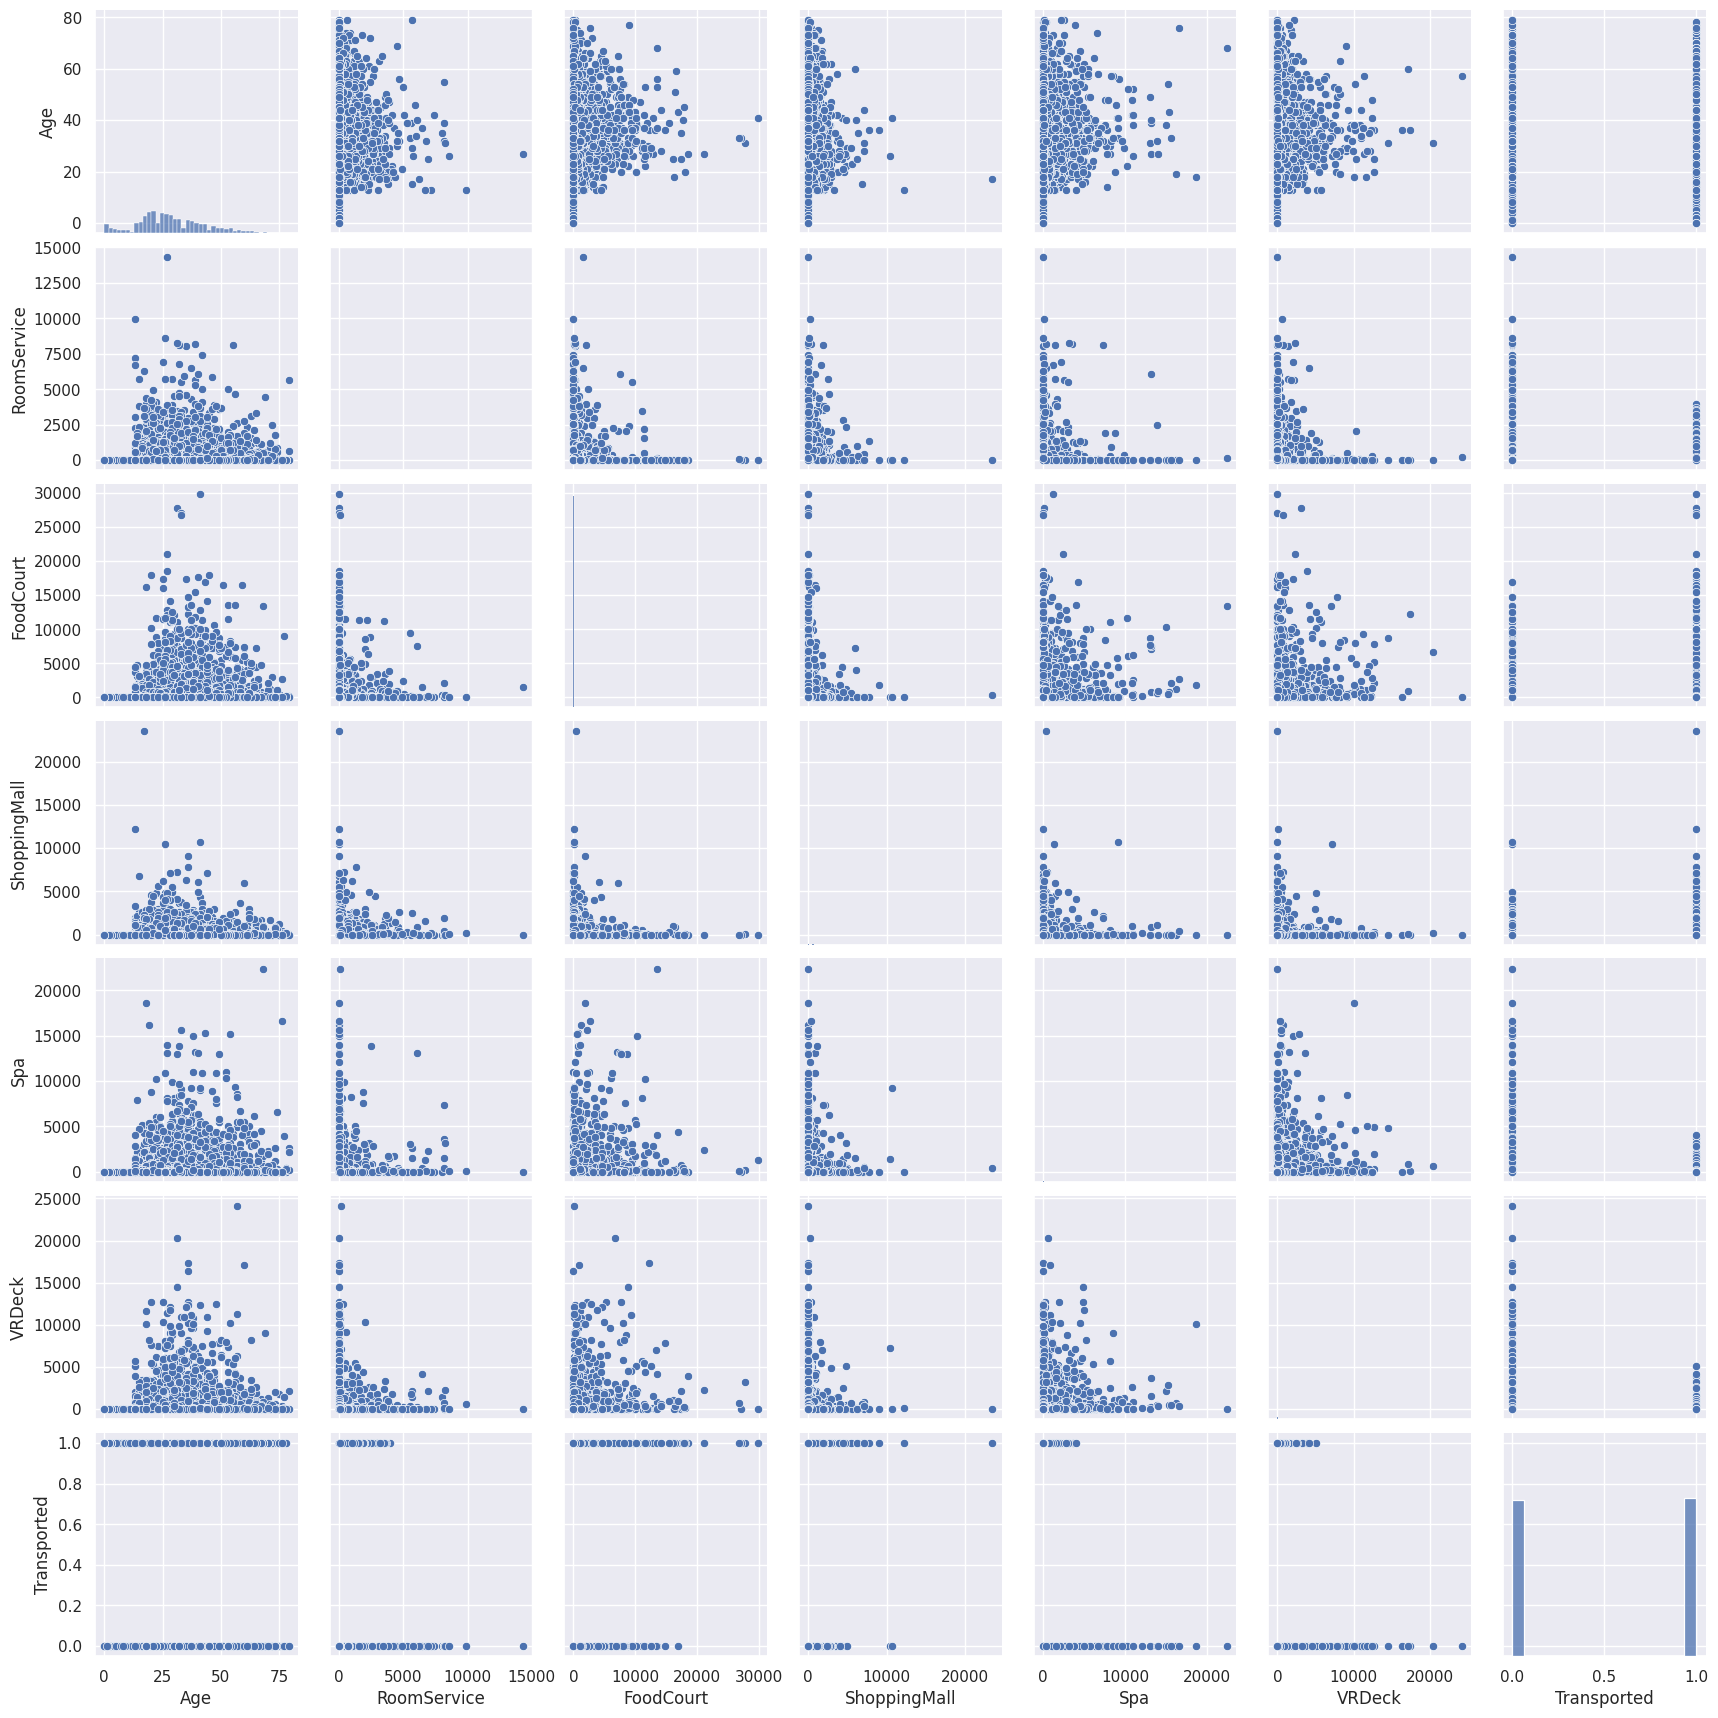

In [ ]:
cols = data_set._get_numeric_data().columns
sns.set()
sns.pairplot(data_set[cols])

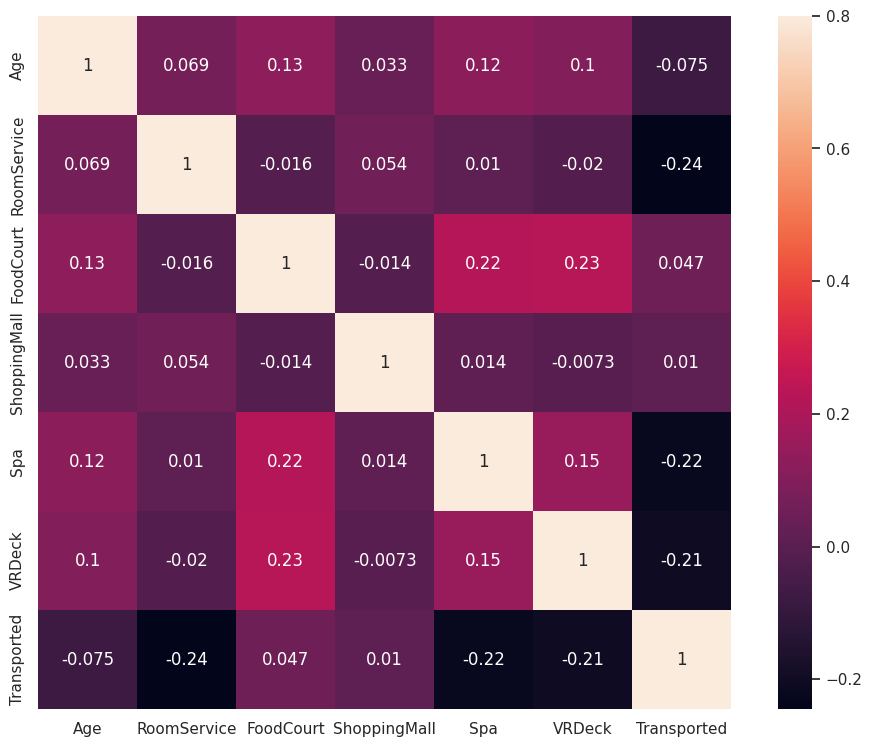

In [ ]:
corrmat = data_set._get_numeric_data().corr()
f, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corrmat,annot = True, vmax=.8, square=True);

No se evidencian relaciones de dependencia severa, siendo las siguientes las unicas significativas :


---



*   RoomService-Transported
*   Spa-Transported
*   VRDeck-Transported
*   FoodCourt-VRDeck
*   FoodCourt-Spa


Recordar que el orden de estas relaciones es indiferente.



In [ ]:
ccols = [i for i in data_set.columns if not i in data_set._get_numeric_data()]
print (ccols)

['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name']


In [ ]:
for c in ccols:
    print ("%10s"%c, np.unique(data_set[c].dropna()))

PassengerId ['0001_01' '0002_01' '0003_01' ... '9279_01' '9280_01' '9280_02']
HomePlanet ['Earth' 'Europa' 'Mars']
 CryoSleep [False True]
     Cabin ['A/0/P' 'A/0/S' 'A/1/S' ... 'T/2/P' 'T/2/S' 'T/3/P']
Destination ['55 Cancri e' 'PSO J318.5-22' 'TRAPPIST-1e']
       VIP [False True]
      Name ['Aard Curle' 'Aarjel Jaff' 'Aarjel Rhuba' ... 'Zosmas Mormonized'
 'Zubeneb Flesping' 'Zubeneb Pasharne']


In [ ]:
for c in data_set.columns:
    print(data_set[c].value_counts())

PassengerId
9280_02    1
0001_01    1
0002_01    1
0003_01    1
0003_02    1
          ..
0008_01    1
0007_01    1
0006_02    1
0006_01    1
0005_01    1
Name: count, Length: 8693, dtype: int64
HomePlanet
Earth     4602
Europa    2131
Mars      1759
Name: count, dtype: int64
CryoSleep
False    5439
True     3037
Name: count, dtype: int64
Cabin
G/734/S     8
B/11/S      7
F/1411/P    7
B/82/S      7
G/981/S     7
           ..
G/543/S     1
B/106/P     1
G/542/S     1
F/700/P     1
G/559/P     1
Name: count, Length: 6560, dtype: int64
Destination
TRAPPIST-1e      5915
55 Cancri e      1800
PSO J318.5-22     796
Name: count, dtype: int64
Age
24.0    324
18.0    320
21.0    311
19.0    293
23.0    292
       ... 
75.0      4
79.0      3
78.0      3
76.0      2
77.0      2
Name: count, Length: 80, dtype: int64
VIP
False    8291
True      199
Name: count, dtype: int64
RoomService
0.0       5577
1.0        117
2.0         79
3.0         61
4.0         47
          ... 
6899.0       1
1954.0

En esta celda de código podemos ver algunos de los valores únicos en las variables no númericas, aquí evidenciamos que Name tiene 8473 valores diferentes y Cabin tiene 6560 valores diferentes, volviendose candidatas a ser eliminadas por aportar muy poca información.

## Preparación de los datos


## Separación de entrenamiento y prueba

## Prevención de fuga de información

## Modelo base


## Modelo predictivo


Entrenamiento del modelo

Interpretación de resultados


## Evaluación del modelo


Validación del modelo


Reproducibilidad

## Almacenamiento del modelo